Okay need to level up alittle yk, so we are going to begin to determine the breeds of theses Dogs and Cats. 

Structure: 
1. First Load the data 
2. Determine how to label the data 
3. How are we going to feed the model the data - what dataloader do we use 
4. Choose a Model 
5. Just run it 
6. Wrap it up about to be the meanest CS major this world has known 

In [23]:
from fastai.vision.all import *

path = untar_data(URLs.PETS)

Step one done we got our data YAYYYYYYY!!!!!!!!!!!!!!!!

In [2]:
path.ls()

files = get_image_files(path/"images")

len(files)

7390

path.ls() - tells us where the files have been downloaded 

get_image_files(path/"images") - Indexes the whole file kinda like a list 

len(files) - we just checking if everything is working 

In [6]:
files[0]

Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_167.jpg')

Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_167.jpg')

So this really is outputing Egyptian_Mau_167.jpg

And so from the last try we know Capital letter for the first letter is a cat and Lower case is dog. Aside from this the whole string till the second _ is the breed. So we need to split the string. 

The ImageDataLoader needs to work on the basis of the filename. So theres are two options: 
1. ImageDataloader.from_name_re
2. ImageDataloader.from_name_func

re - just means regex https://www.w3schools.com/python/python_regex.asp

Link above is a good resource to learn about it 

func - just means we made a function prior and will use it in the dataloader function. 

We are going to be using the re one cause seems kinda cool (Claude may have helped with writing this :[)

In [3]:
import re 

name = files[0].name 

math = re.match(r"^(.+)_\d+.jpg$", name)

print(math.group(1))

Egyptian_Mau


In [4]:
pat = r'^(.+)_\d+\.jpg$'

dls = ImageDataLoaders.from_name_re(path, files, pat, valid_pct = 0.2 , item_tfms = Resize(460))

I didn't do it but there is a function called: 

batch_tfms=aug_transforms(size=224) - bassically crops the images randomly and forces the model to pick up on the patterns better. 

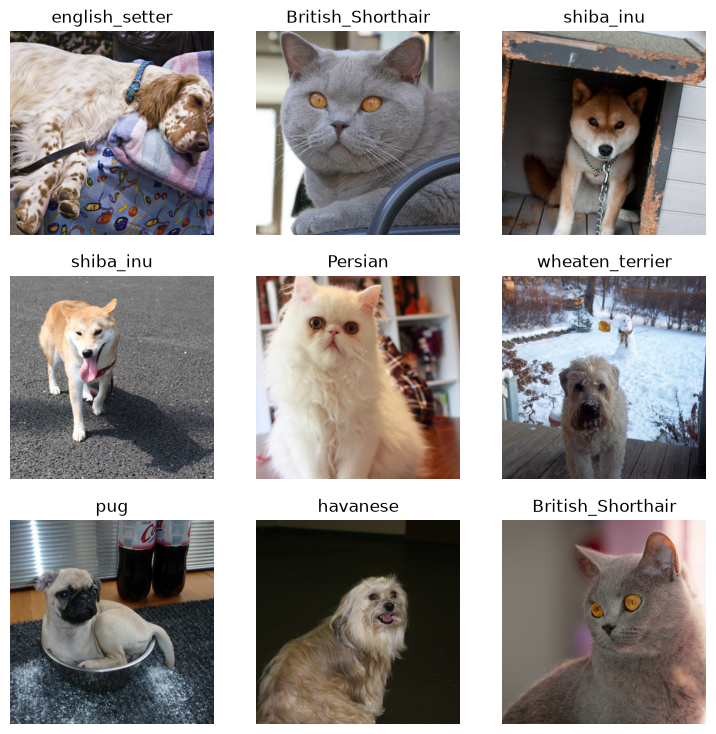

In [5]:
dls.show_batch()

<div></div>

SuggestedLRs(valley=0.0020892962347716093)

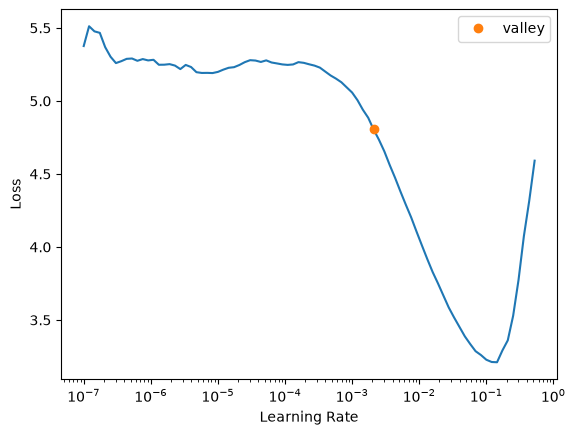

In [6]:
learn = vision_learner(dls, resnet34, metrics=error_rate)

learn.lr_find()

So the plot helps us determine the max adjustments to make to the model each time we retrain/each epoch. So from the plot above the dot tells us to max make an adjustment of 1.4e-3. 

Reading your curve:
1. Flat and high on the left (10⁻⁷ to 10⁻⁴) → learning rate too tiny, no progress
2. Steep drop (10⁻³ to 10⁻¹) → the sweet spot, model learning fast
3. Sharp spike up past 10⁻¹ → too big, model going unstable

If the adjustments are too little the model takes forver to actually leanr any patterns at all.

If the adjustments are too large again it isn't actually learning 



In [7]:
learn.fine_tune(3,2.08e-3)

epoch,train_loss,valid_loss,error_rate,time
0,1.654375,0.329171,0.100135,01:20


epoch,train_loss,valid_loss,error_rate,time
0,0.436070,0.268009,0.087280,01:51
1,0.256169,0.175918,0.053451,01:56
2,0.125578,0.152515,0.043978,02:02


We were guesing how many times to train the model, so a rule of thumb is: 

The real signal comes from the training table, not the lr_find graph. Once you start training, fastai shows you train_loss, valid_loss, and error_rate after every epoch. You watch those numbers to decide if you've run enough:

    Keep training if valid_loss and error_rate are still dropping each epoch — the model is still improving, so more epochs help.

    Stop when they flatten out (no more improvement) or — the key warning sign — when valid_loss starts rising while train_loss keeps falling. 

    That gap means overfitting: the model is memorizing training images instead of learning general patterns. That's your "too many epochs" signal.



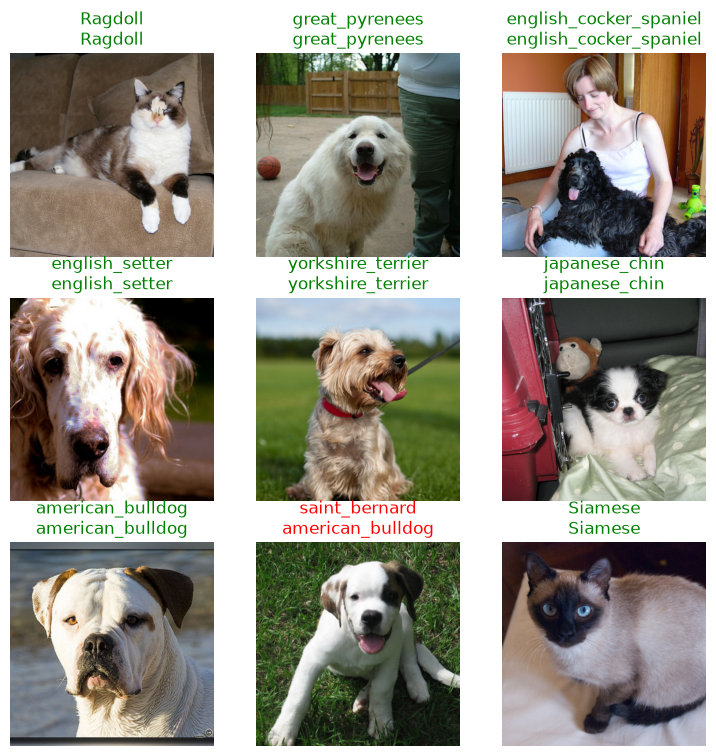

In [8]:
learn.show_results()

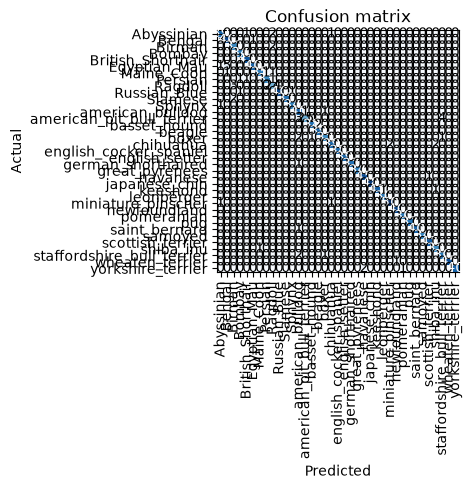

In [9]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
     

Kinda just not useful info icl soooooooooo need to keep in my mind the nuyber of categorical variables is important

<Axes: >

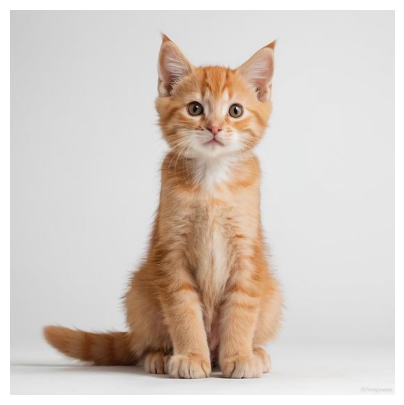

In [18]:
img = PILImage.create("cat.jpg")

img.show()

In [10]:
learn.predict("cat.jpg")

('Maine_Coon',
 tensor(6),
 tensor([1.4816e-04, 7.4908e-04, 4.2741e-07, 2.4050e-07, 2.6273e-07, 1.0317e-05,
         9.9908e-01, 9.7190e-07, 7.1845e-06, 7.9302e-09, 9.0795e-08, 8.1003e-07,
         9.0408e-10, 6.5268e-08, 2.1176e-08, 3.1343e-08, 2.1655e-09, 1.1596e-07,
         7.2149e-08, 4.8853e-07, 2.3443e-10, 1.6983e-08, 2.5514e-08, 1.1401e-07,
         5.9777e-09, 1.8772e-07, 6.1591e-09, 2.9093e-08, 2.2311e-08, 9.3511e-09,
         1.9112e-06, 2.8709e-09, 1.5567e-08, 1.4450e-07, 3.8087e-09, 1.7367e-07,
         7.8353e-08]))

So the above lets us predict a single isntance but now we want to kinda level up, and deploy the model with an API so anyone can use. 

We are gonna do this in two steps, first deploy on hugging face with a simple interface using Gradio. It'll come with an API key as well so we can just use it.

But First we need to download the model as a pickle 

In [14]:
learn.export("model.pkl")

In [13]:
import os 

print(os.getcwd())

/Users/shshankj/Desktop/52_Hard/Image_Classifier


Alittle claude help goes along way, if you also face the same issue, try the below code but change the file path ofc. 

Main issue was the fact that it didn't know where to save the file. 

In [16]:
import os

# Check current directory
print("Working directory:", os.getcwd())

# Try the export with explicit path
try:
    learn.export("/Users/shshankj/Desktop/52_Hard/Image_Classifier/model.pkl")
    print("Export completed")
    
    # Check if file exists
    if os.path.exists("model.pkl"):
        size = os.path.getsize("model.pkl")
        print(f"✅ File created! Size: {size / (1024**2):.1f} MB")
    else:
        print("❌ File not found after export")
        
except Exception as e:
    print(f"❌ Export failed: {e}")

Working directory: /Users/shshankj/Desktop/52_Hard/Image_Classifier
Export completed
✅ File created! Size: 83.6 MB


In [21]:
learn.predict("GR.jpg")

('english_setter',
 tensor(19),
 tensor([2.4232e-05, 4.6964e-05, 3.9055e-05, 9.0485e-06, 9.3010e-08, 2.1805e-05,
         1.4954e-03, 3.3733e-05, 1.1286e-04, 3.7997e-07, 2.2730e-05, 8.0892e-06,
         6.3460e-05, 3.9517e-06, 8.9882e-04, 1.4596e-03, 8.1127e-06, 4.4737e-06,
         1.3529e-01, 4.5213e-01, 9.3951e-04, 4.0186e-01, 3.9589e-04, 1.1905e-03,
         1.2491e-04, 8.4828e-04, 8.4243e-06, 1.0761e-03, 6.0856e-05, 6.3861e-06,
         3.7515e-04, 1.1239e-03, 1.2857e-05, 1.1843e-05, 1.4314e-05, 2.4425e-04,
         3.3729e-05]))